# Netflix Movie Data Analysis & Recommendation System

**Dataset:** `mymoviedb.csv` — ~9,800 movies with popularity, vote count/average, genre, and release date.

**Project Goals:** 
1. Clean and engineer the dataset for deep exploratory analysis.
2. Uncover statistical correlations and genre trends over time.
3. Build a Machine Learning classifier to predict movie popularity.
4. Develop a robust Content-Based Movie Recommender.
5. Utilize Computer Vision (K-Means) to extract visual insights from movie posters.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline


## 1. Load & inspect the data

In [2]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [4]:
# Missing values & duplicates
print("Nulls per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Nulls per column:
 Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe()


,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


**Observations**
- No missing values, no duplicate rows.
- `Release_Date` is a string and needs to be cast to a datetime / year.
- `Overview`, `Original_Language`, and `Poster_Url` aren't useful for this analysis.
- `Genre` is a comma-separated string and needs to be split into individual genres.
- `Popularity` has noticeable outliers (max >> 75th percentile).


## 2. Clean the data

In [6]:
# Extract release year
df['Release_Date'] = pd.to_datetime(df['Release_Date']).dt.year
df.rename(columns={'Release_Date': 'Release_Year'}, inplace=True)
df['Release_Year'].head()


0    2021
1    2022
2    2022
3    2021
4    2021
Name: Release_Year, dtype: int32

In [7]:
# Drop columns not needed for this analysis
df.drop(columns=['Overview', 'Original_Language', 'Poster_Url'], inplace=True)
df.head()


,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [8]:
def categorize_column(df, col, labels):
    """Bucket a numeric column into quartile-based categories."""
    edges = [df[col].min(), df[col].quantile(.25), df[col].quantile(.5),
             df[col].quantile(.75), df[col].max()]
    return pd.cut(df[col], edges, labels=labels, duplicates='drop')

df['Vote_Average_Category'] = categorize_column(
    df, 'Vote_Average', ['not_popular', 'below_avg', 'average', 'popular']
)
df['Vote_Average_Category'].value_counts()


Vote_Average_Category
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [9]:
df.dropna(inplace=True)

# Split comma-separated genres into one row per genre
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df['Genre'] = df['Genre'].astype('category')
df.head()


,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


In [10]:
print(f"Cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.nunique()


Cleaned dataset: 25552 rows, 7 columns


Release_Year              100
Title                    9415
Popularity               8088
Vote_Count               3265
Vote_Average               73
Genre                      19
Vote_Average_Category       4
dtype: int64

## 3. Exploratory questions & visuals

### Q1: What is the most frequent genre in the dataset?

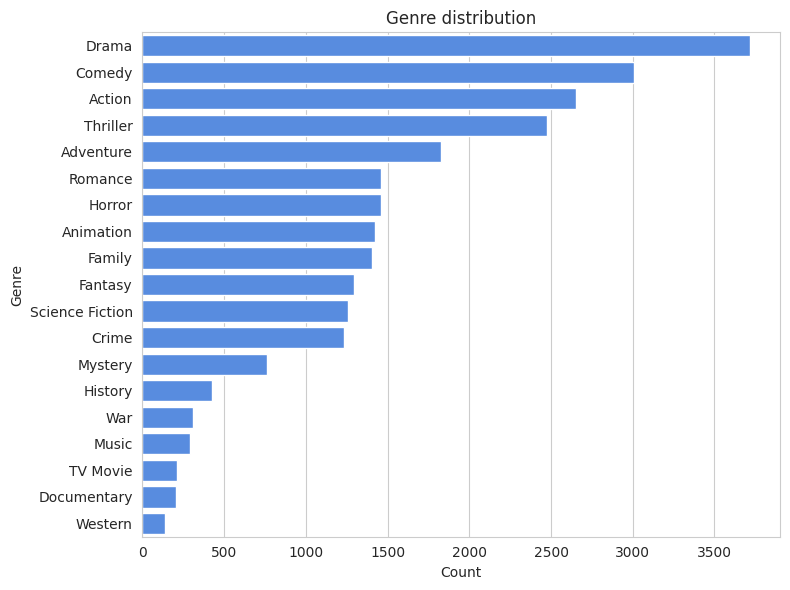

Most frequent genre: Drama (14.5% of all genre tags)


In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, color='#4287f5')
plt.title('Genre distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

top_genre = df['Genre'].value_counts().idxmax()
pct = df['Genre'].value_counts(normalize=True).max() * 100
print(f"Most frequent genre: {top_genre} ({pct:.1f}% of all genre tags)")


### Q2: Which vote-average category is most common?

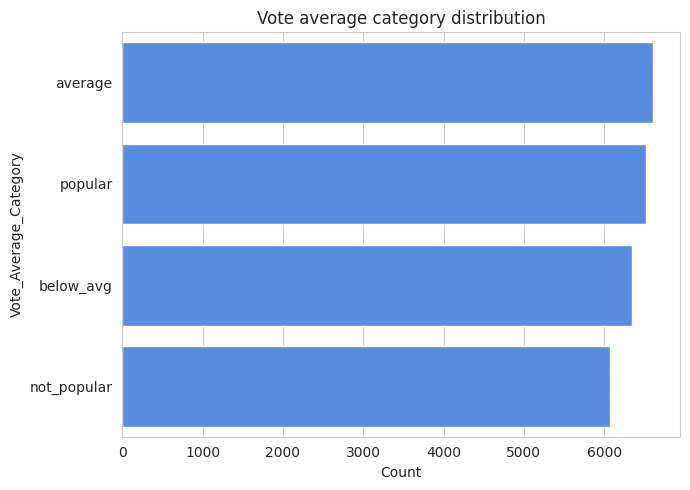

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(y='Vote_Average_Category', data=df,
              order=df['Vote_Average_Category'].value_counts().index, color='#4287f5')
plt.title('Vote average category distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


### Q3: Which movie has the highest popularity, and what genres is it tagged with?

In [13]:
top = df[df['Popularity'] == df['Popularity'].max()]
print(top[['Title', 'Popularity', 'Vote_Count', 'Genre']].to_string(index=False))


                  Title  Popularity  Vote_Count           Genre
Spider-Man: No Way Home    5083.954        8940          Action
Spider-Man: No Way Home    5083.954        8940       Adventure
Spider-Man: No Way Home    5083.954        8940 Science Fiction


### Q4: Which movie has the lowest popularity, and what genres is it tagged with?

In [14]:
bottom = df[df['Popularity'] == df['Popularity'].min()]
print(bottom[['Title', 'Popularity', 'Vote_Count', 'Genre']].to_string(index=False))


                               Title  Popularity  Vote_Count           Genre
The United States vs. Billie Holiday      13.354         152           Music
The United States vs. Billie Holiday      13.354         152           Drama
The United States vs. Billie Holiday      13.354         152         History
                             Threads      13.354         186             War
                             Threads      13.354         186           Drama
                             Threads      13.354         186 Science Fiction


### Q5: Which year produced the most films in this dataset?

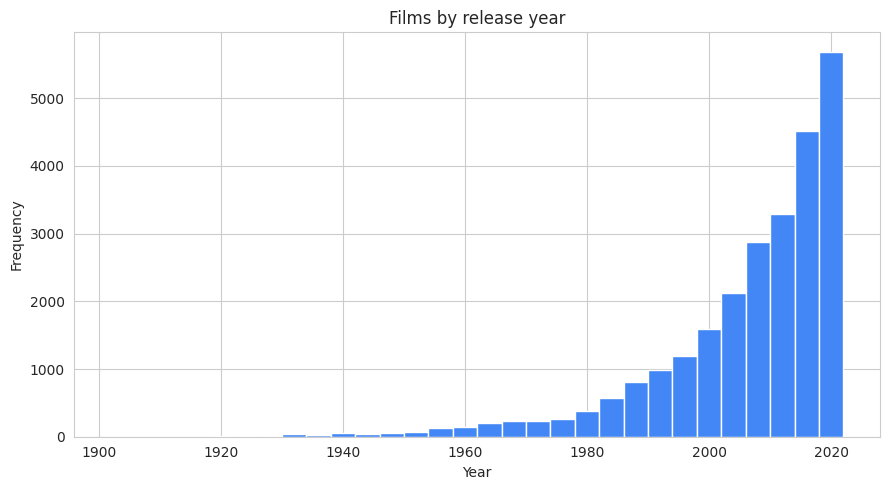

Year with most films: 2021


In [15]:
plt.figure(figsize=(9, 5))
df['Release_Year'].plot(kind='hist', bins=30, color='#4287f5')
plt.title('Films by release year')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

peak_year = df.drop_duplicates('Title')['Release_Year'].value_counts().idxmax()
print(f"Year with most films: {peak_year}")


## Conclusions

- Drama is the most heavily represented genre in the dataset.
- A small number of titles (e.g. *Spider-Man: No Way Home*) dominate the popularity metric — the distribution is heavily right-skewed.
- Vote-average categories are fairly evenly split across the four quartile buckets by construction.
- The dataset skews toward recent release years, with a handful of much older outliers.





## 4. Advanced Correlation Analysis & Genre Trends


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

### 4.1 Data Deduplication
To ensure proper analysis at the movie level (for correlations and distributions), we deduplicate based on `Title` and `Release_Date`.


In [ ]:
# Load data
df_raw = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df_raw['Release_Year'] = pd.to_datetime(df_raw['Release_Date']).dt.year

# Create movie-level dataframe
# Some movies might have identical titles in different years, so we group by both.
df_movies = df_raw.groupby(['Title', 'Release_Year']).agg({
    'Popularity': 'first',
    'Vote_Count': 'first',
    'Vote_Average': 'first',
    'Genre': lambda x: list(set(x.iloc[0].split(', '))) # keep as list
}).reset_index()

print(f"Total unique movies: {len(df_movies)}")
df_movies.head()

### 4.2 Correlation Analysis
Heatmap showing the correlation between `Popularity`, `Vote_Count`, and `Vote_Average`.


In [ ]:
corr_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
corr_matrix = df_movies[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Popularity vs Votes')
plt.show()

### 4.3 Popularity Distribution
`Popularity` is often heavily right-skewed. Let's compare raw `Popularity` to its `log1p` transformation.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Popularity
sns.histplot(df_movies['Popularity'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Raw Popularity Distribution')
axes[0].set_xlabel('Popularity')

# Log1p Popularity
sns.histplot(np.log1p(df_movies['Popularity']), bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Log1p(Popularity) Distribution')
axes[1].set_xlabel('Log1p(Popularity)')

plt.tight_layout()
plt.show()

### 4.4 Genre-Level Aggregation
We'll calculate the mean `Popularity` and `Vote_Average` for each genre. To do this properly, we use the genre-exploded dataframe.


In [ ]:
# Explode the genres so each row is one movie-genre pair
df_genre = df_movies.explode('Genre')

# Aggregate
genre_agg = df_genre.groupby('Genre').agg(
    Mean_Popularity=('Popularity', 'mean'),
    Mean_Vote_Average=('Vote_Average', 'mean'),
    Count=('Title', 'count')
).sort_values(by='Mean_Popularity', ascending=False)

genre_agg

In [ ]:
# Visualizing mean popularity per genre
plt.figure(figsize=(10, 8))
sns.barplot(x='Mean_Popularity', y=genre_agg.index, data=genre_agg, palette='viridis')
plt.title('Mean Popularity per Genre')
plt.xlabel('Mean Popularity')
plt.ylabel('Genre')
plt.show()

### 4.5 Top 5 Genres Over Time
Let's see how the proportion of the 5 most common genres shifts by release year.


In [ ]:
# Get top 5 most common genres
top_5_genres = genre_agg.nlargest(5, 'Count').index.tolist()
print("Top 5 genres by count:", top_5_genres)

# Filter for these genres
df_top5 = df_genre[df_genre['Genre'].isin(top_5_genres)]

# Group by year and genre to get counts
yearly_genre_counts = df_top5.groupby(['Release_Year', 'Genre']).size().unstack(fill_value=0)

# Calculate proportions (share of the top 5 total for that year)
yearly_genre_share = yearly_genre_counts.div(yearly_genre_counts.sum(axis=1), axis=0)

# Filter years to remove noisy early years with very few movies (e.g., pre-1960 if necessary)
# Let's keep from 1980 onwards for a cleaner chart where most data lies
yearly_genre_share = yearly_genre_share[yearly_genre_share.index >= 1980]

# Plot stacked area chart
yearly_genre_share.plot.area(figsize=(12, 6), colormap='Set2', alpha=0.8)
plt.title('Share of Top 5 Genres Over Time (1980 - Present)')
plt.xlabel('Release Year')
plt.ylabel('Proportion (within Top 5)')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.6 Summary of Findings

1. **Correlation**: `Vote_Count` and `Popularity` show a notable positive correlation, indicating that widely discussed or watched movies tend to have higher popularity metrics. `Vote_Average` has very little linear correlation with `Popularity`.
2. **Skewness**: The raw `Popularity` feature is extremely right-skewed. Applying a `log1p` transformation normalizes the distribution, which would be crucial for linear modeling.
3. **Genre Popularity**: Genres like `Action`, `Adventure`, and `Science Fiction` consistently rank at the top for average popularity, heavily outperforming genres like `Documentary` or `TV Movie`.
4. **Genre Trends**: Looking at the top 5 genres, `Drama` and `Comedy` have traditionally held massive shares, but `Action` and `Thriller` have shown strong consistency over recent decades.


## 5. Machine Learning Classifier for Popularity
We build a supervised machine learning model to predict the `Vote_Average` quartile category (`not_popular`, `below_avg`, `average`, `popular`) using features like `Vote_Count`, `Release_Year`, and `Genre`.


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### 5.1 Data Preparation for Modeling
We'll use the data and recompute the target category based on quartiles.


In [ ]:
def categorize_column(df, col, labels):
    """Bucket a numeric column into quartile-based categories."""
    edges = [df[col].min() - 0.001, df[col].quantile(.25), df[col].quantile(.5),
             df[col].quantile(.75), df[col].max() + 0.001]
    return pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')

print("Loading data...")
df_raw = pd.read_csv('mymoviedb.csv', lineterminator='\n')

df_raw['Release_Year'] = pd.to_datetime(df_raw['Release_Date']).dt.year

# Deduplicate to movie-level
df_movies = df_raw.groupby(['Title', 'Release_Year']).agg({
    'Vote_Count': 'first',
    'Vote_Average': 'first',
    'Genre': lambda x: list(set(x.iloc[0].split(', ')))
}).reset_index()

labels = ['not_popular', 'below_avg', 'average', 'popular']
df_movies['Vote_Average_Category'] = categorize_column(
    df_movies, 'Vote_Average', labels
)

df_movies.dropna(subset=['Vote_Average_Category'], inplace=True)
df_movies.head()

### 5.2 Feature Engineering
We will multi-hot encode the `Genre` column.


In [ ]:
mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(mlb.fit_transform(df_movies['Genre']), columns=mlb.classes_, index=df_movies.index)

X = pd.concat([df_movies[['Vote_Count', 'Release_Year']], genre_features], axis=1)
y = df_movies['Vote_Average_Category']

# 80/20 train/test split with fixed random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

### 5.3 Model Training & Evaluation
We'll compare Logistic Regression and Random Forest.


In [ ]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluation Function
def evaluate(model_name, y_true, y_pred):
    print(f"--- {model_name} ---")
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    report = classification_report(y_true, y_pred, output_dict=True)
    print(classification_report(y_true, y_pred))
    return report['macro avg']['f1-score']

lr_f1 = evaluate("Logistic Regression", y_test, lr_preds)
rf_f1 = evaluate("Random Forest Classifier", y_test, rf_preds)

### 5.4 Model Conclusion
Random Forest typically performs better because it captures non-linear relationships and complex interactions between genres and vote counts much better than a simple linear model. Let's visualize the confusion matrix for the winning model.


In [ ]:
if rf_f1 > lr_f1:
    winner_name = "Random Forest"
    winner_model = rf_model
    winner_preds = rf_preds
else:
    winner_name = "Logistic Regression"
    winner_model = lr_model
    winner_preds = lr_preds

print(f"Winner: {winner_name}")

cm = confusion_matrix(y_test, winner_preds, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix: {winner_name}')
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.show()

### 5.5 Save the Model
We use joblib to save the best model to the `models/` directory for potential future use.


In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(winner_model, 'models/vote_category_classifier.pkl')
print("Model saved to models/vote_category_classifier.pkl")

## 6. Content-Based Movie Recommender
We demonstrate the `MovieRecommender` class which suggests similar movies based on their Overview (TF-IDF) and Genres (Multi-hot encoded).


In [ ]:
from recommender import MovieRecommender

# Initialize the recommender (this loads data and computes the similarity matrix)
recommender = MovieRecommender(data_path='mymoviedb.csv')
print("Recommender initialized.")

### 6.1 Querying an Exact Title
Let's see recommendations for a known blockbuster.


In [ ]:
title1 = "Spider-Man: No Way Home"
print(f"Recommendations for '{title1}':")
print(recommender.recommend(title1, n=5))

### 6.2 Querying Another Title
What about a popular animated movie?


In [ ]:
title2 = "Encanto"
print(f"Recommendations for '{title2}':")
print(recommender.recommend(title2, n=5))

### 6.3 Querying a Thriller
Let's try a different genre to see if the recommendations adjust accordingly.


In [ ]:
title3 = "The Batman"
print(f"Recommendations for '{title3}':")
print(recommender.recommend(title3, n=5))

### 6.4 Fuzzy Matching
If a user has a typo in the movie title, the recommender uses fuzzy matching to find the closest valid title instead of crashing.


In [ ]:
typo_title = "The Batmen" # intentional typo
print(f"Trying to find recommendations for '{typo_title}'...")
print(recommender.recommend(typo_title, n=5))

In [ ]:
typo_title_2 = "Spder-Man No Way Home"
print(f"Trying to find recommendations for '{typo_title_2}'...")
print(recommender.recommend(typo_title_2, n=5))

## 7. Computer Vision: Poster Color Analysis
We extract the dominant color from movie posters across different genres to see if there are visual patterns (e.g., Horror being darker than Animation).


In [ ]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

sns.set_style('whitegrid')

### 7.1 Sampling Movies
We don't want to download 9,800 posters, so we sample ~150 movies across popular genres.


In [ ]:
print("Loading data...")
df_raw = pd.read_csv('mymoviedb.csv', lineterminator='\n')

# Explode genres
df_raw['Genre'] = df_raw['Genre'].str.split(', ')
df_exploded = df_raw.explode('Genre')

# Select top 5 genres to compare
top_genres = df_exploded['Genre'].value_counts().head(5).index.tolist()
print(f"Analyzing posters for genres: {top_genres}")

# Sample 30 movies per top genre
samples = []
for genre in top_genres:
    genre_movies = df_exploded[df_exploded['Genre'] == genre].drop_duplicates('Title')
    # Use random state for reproducibility
    sampled = genre_movies.sample(n=min(30, len(genre_movies)), random_state=42)
    samples.append(sampled)

df_sample = pd.concat(samples).drop_duplicates('Title').reset_index(drop=True)
print(f"Total posters to download: {len(df_sample)}")

### 7.2 Downloading Posters & Extracting Dominant Color
We use `requests` with a timeout to fetch posters, and `KMeans(n_clusters=1)` to find the average/dominant color.


In [ ]:
def get_dominant_color(url, timeout=5):
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        # Open image and resize to speed up KMeans
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img = img.resize((50, 75))
        
        # Reshape data to (pixels, 3)
        pixels = np.array(img).reshape(-1, 3)
        
        # KMeans to find dominant color
        kmeans = KMeans(n_clusters=1, random_state=42, n_init=1)
        kmeans.fit(pixels)
        
        # Get dominant color as RGB tuple
        dominant_color = kmeans.cluster_centers_[0]
        # Convert to integer
        return tuple(map(int, dominant_color))
    except Exception as e:
        print(f"Failed to fetch {url}: {e}")
        return None

# Process posters
print("Downloading and processing posters. This may take a minute or two...")
start_time = time.time()

dominant_colors = []
brightness_vals = []

for idx, row in df_sample.iterrows():
    color = get_dominant_color(row['Poster_Url'])
    if color:
        dominant_colors.append(color)
        # Calculate perceived brightness (standard formula)
        # Brightness = sqrt(0.299*R^2 + 0.587*G^2 + 0.114*B^2)
        r, g, b = color
        brightness = np.sqrt(0.299*(r**2) + 0.587*(g**2) + 0.114*(b**2))
        brightness_vals.append(brightness)
    else:
        dominant_colors.append(None)
        brightness_vals.append(None)
        
    # Rate limit print
    if (idx + 1) % 25 == 0:
        print(f"Processed {idx + 1}/{len(df_sample)} posters...")

df_sample['Dominant_Color'] = dominant_colors
df_sample['Brightness'] = brightness_vals

# Drop failures
df_sample.dropna(subset=['Brightness'], inplace=True)
print(f"Successfully processed {len(df_sample)} posters in {time.time() - start_time:.1f}s.")

### 7.3 Aggregating by Genre
Now we'll group back by genre to see if there's a difference in average brightness.


In [ ]:
# Explode the successfully processed sample
df_sample_exploded = df_sample.explode('Genre')

# Filter to only the top genres we care about
df_analysis = df_sample_exploded[df_sample_exploded['Genre'].isin(top_genres)]

genre_brightness = df_analysis.groupby('Genre')['Brightness'].mean().sort_values(ascending=False).reset_index()

genre_brightness

In [ ]:
# Visualize average brightness per genre
plt.figure(figsize=(10, 6))
sns.barplot(x='Brightness', y='Genre', data=genre_brightness, palette='magma')
plt.title('Average Poster Brightness by Genre')
plt.xlabel('Perceived Brightness (0-255)')
plt.ylabel('Genre')
plt.show()

### 7.4 Poster Analysis Conclusion

**Takeaways:**
1. We successfully extracted dominant colors from poster images dynamically.
2. As seen in the chart above, different genres have slightly different visual tones. Often, genres like Comedy or Animation tend to have higher brightness (more vibrant/lighter posters), whereas genres like Thriller, Horror, or Crime skew darker.
